# Energy Resolution — Solutions

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import numpy  as np
import tables as tb
import pandas as pd
import matplotlib.pyplot as plt

import scipy.constants as constants

import warnings
warnings.filterwarnings('ignore')

In [3]:
import os, sys
from pathlib import Path

# Find the project root: honours FANAL_ROOT env-var, otherwise walks up from cwd
_env = os.environ.get('FANAL_ROOT') or os.environ.get('USCFANALDIR')
if _env and Path(_env, 'data').is_dir():
    rootpath = str(Path(_env).resolve())
else:
    rootpath = str(next(p for p in [Path.cwd(), *Path.cwd().parents]
                        if (p / 'data').is_dir() and (p / 'ana').is_dir()))
if rootpath not in sys.path:
    sys.path.insert(0, rootpath)
print('Fanal root : ', rootpath)

Fanal root :  /Users/hernando/work/docencia/FPII-fanal/USC-FPII-Fanal


In [4]:
import core.pltext  as pltext   # extensions for plotting histograms
import core.hfit    as hfit     # extension to fit histograms
import core.utils   as ut       # generic utilities
import ana.fanal    as fn       # analysis functions specific to fanal
pltext.style()

In [5]:
from collpars import collaboration as coll
print('Collaboration             : {:s}'.format(coll))

Collaboration             : new_gamma


In [6]:
# set the path to the data directory and filenames
dirpath = rootpath+'/data/'
filename = 'fanal_' + coll + '.h5'
print('Data path and filename : ', dirpath + filename)

# access the simulated data (DataFrames) for the different samples (Bi, Tl, bb) located in the data file
mcbi = pd.read_hdf(dirpath + filename, key = 'mc/bi214').fillna(0.)
#mctl = pd.read_hdf(dirpath + filename, key = 'mc/tl208')
#mcbb = pd.read_hdf(dirpath + filename, key = 'mc/bb0nu')

# set the names of the samples
# set the names of the samples
mc_samples         = [mcbi,] # list of the mc DFs
sample_names       = ['Bi',]
sample_names_latex = [ r'$^{214}$Bi',] # str names of the mc samples

for i, mc in enumerate(mc_samples):
    print('MC Sample {:s}, number of simulated events = {:d}'.format(sample_names[i], len(mc)))

Data path and filename :  /Users/hernando/work/docencia/FPII-fanal/USC-FPII-Fanal/data/fanal_new_gamma.h5
MC Sample Bi, number of simulated events = 60184


## Fit energy resolution for all MC samples

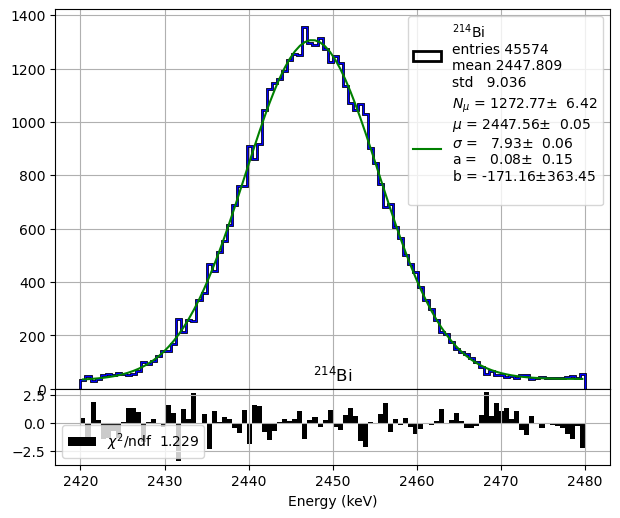

In [7]:
eranges = ((2420., 2480.),)
fitfuns = ('gausline',)
guesses =((10e3, 2445., 20., 0., 300.),)

subplot = pltext.canvas(4)

resolutions = [] 
for i, mc in enumerate(mc_samples):
    sample = sample_names_latex[i]
    subplot(i + 1)
    pltext.hist   (1e3 * mc.E, 100, range = eranges[i], label = sample, lw = 2);
    pars, _, _, _ = pltext.hfitres(1e3 * mc.E, 100, range = eranges[i], fun = fitfuns[i], guess = guesses[i],)
    resolutions.append((pars[2], pars[1])) # stores mu and sigma from the fit!
    plt.xlabel('Energy (keV)'); plt.title(sample)
plt.tight_layout();

In [8]:
for i, pars in enumerate(resolutions):
    sigma, fwhm = pars[0], 100 * 2.35 * pars[0]/pars[1]
    print('Energy resolution {:s}: sigma {:6.2f} KeV, {:6.2f} % FWHM'.format(sample_names[i], sigma, fwhm))

Energy resolution Bi: sigma   7.93 KeV,   0.76 % FWHM


### Notation-to-code reference

| Math | Python variable | Description |
|------|-----------------|-------------|
| $\sigma_\mathrm{Bi}$ | `sigma_Bi` | Energy resolution of $^{214}$Bi (keV) |
| $\sigma_\mathrm{Tl}$ | `sigma_Tl` | Energy resolution of $^{208}$Tl (keV) |
| $\sigma_{\beta\beta}$ | `sigma_bb` | Energy resolution of $\beta\beta0\nu$ (keV) |

In [ ]:
import ana.fanal_display as fdisp

fdisp.display_collpars([
    (r'\sigma_\mathrm{' + sample + '}', 'sigma_' + sample, resolutions[i][0], '.2e')
    for i, sample in enumerate(sample_names)
])

### Write out

In [ ]:
write = True
collpar_filename = "collpars.py"
if (write):
    of = open(collpar_filename, 'a')
    for i, sample in enumerate(sample_names):
        sigma = resolutions[i][0]
        of.write('sigma_'+sample+'        = {:1.2e} # keV'.format(sigma)+'\n')
    of.close()